In [19]:
# import required python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import math

print(yf.__version__)

1.2.0


In [ ]:
# HELPER FUNCTIONS
def highpass_filter(price, period):
    price = np.asarray(price, dtype=float)
    n = len(price)
    hp = np.zeros(n, dtype=float)

    Q  = math.exp(-1.414 * math.pi / period)
    c1 = 2 * Q * math.cos(1.414 * math.pi / period)
    c2 = Q * Q
    a0 = (1 + c1 + c2) / 4.0

    for t in range(2, n):
        hp[t] = (
            a0 * (price[t] - 2 * price[t-1] + price[t-2]) +
            c1 * hp[t-1] -
            c2 * hp[t-2]
        )
    return hp


def bandpass_single_step(close, bp_prev1, bp_prev2, period, bandwidth):

    if period <= 0:
        return 0.0

    L1 = math.cos(2 * math.pi / period)
    G1 = math.cos(bandwidth * 2 * math.pi / period)
    S1 = 1.0 / G1 - math.sqrt(1.0 / (G1 * G1) - 1.0)

    return (
        0.5 * (1.0 - S1) * (close[0] - close[2]) +
        L1 * (1.0 + S1) * bp_prev1 -
        S1 * bp_prev2
    )


In [39]:
# Retrieve price data via Yahoo Finance

symbol = '^GSPC'
symbol = 'ES=F'
ohlcv = yf.download(
    symbol, 
    start="2000-01-01", 
    end="2026-03-18", 
    group_by="Ticker",
    auto_adjust=True,
    progress=False,
)
ohlcv = ohlcv.stack('Ticker', future_stack=True).reset_index().set_index('Date')
ohlcv

Price,Ticker,Open,High,Low,Close,Volume
Date,,,,,,
2000-09-18,ES=F,1485.25,1489.75,1462.25,1467.50,104794
2000-09-19,ES=F,1467.00,1482.75,1466.75,1478.50,103371
2000-09-20,ES=F,1478.75,1480.50,1450.25,1469.50,109667
2000-09-21,ES=F,1470.25,1474.00,1455.50,1469.50,98528
2000-09-22,ES=F,1454.75,1471.00,1436.75,1468.50,97416
...,...,...,...,...,...,...
2026-03-12,ES=F,6766.00,6769.50,6671.75,6677.50,2042016
2026-03-13,ES=F,6684.25,6737.50,6625.00,6636.00,2407679
2026-03-16,ES=F,6608.50,6734.25,6608.50,6704.75,2025388


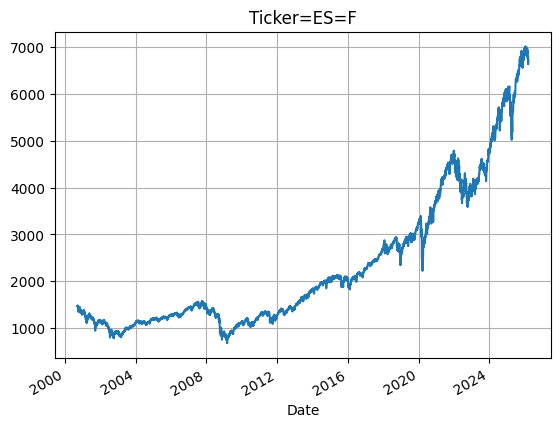

In [47]:
# inspect closing price line plot
ax = ohlcv['Close'].plot(grid=True, title=f'Ticker={symbol}')

In [48]:
# AutoTune Indicator and AutoTune Plot functions

def autotune_indicator(close, window=20, bp_bandwidth=0.25):
    
    close = np.asarray(close, dtype=float)
    n = len(close)

    filt = highpass_filter(close, window)
    mincorr = np.ones(n, dtype=float)
    dc = np.zeros(n, dtype=float)
    bp = np.zeros(n, dtype=float)

    for t in range(window, n):
        # correlation window: last `window` filt values ending at t
        x = filt[t-window+1 : t+1]  # length = window

        # For each lag = 1..window, compute correlation with lagged version
        best_corr = 1.0
        best_lag = 1

        for lag in range(1, window + 1):
            # y is x shifted back by `lag` bars in the underlying filt series
            idx_start = t - window + 1 - lag
            idx_end   = t + 1 - lag

            if idx_start < 0:
                continue

            y = filt[idx_start:idx_end]
            if len(y) != window:
                continue

            Sx = x.sum()
            Sy = y.sum()
            Sxx = np.dot(x, x)
            Syy = np.dot(y, y)
            Sxy = np.dot(x, y)

            denom_x = window * Sxx - Sx * Sx
            denom_y = window * Syy - Sy * Sy
            if denom_x <= 0 or denom_y <= 0:
                continue

            corr = (window * Sxy - Sx * Sy) / math.sqrt(denom_x * denom_y)
            if corr < best_corr:
                best_corr = corr
                best_lag = lag

        # Dominant cycle
        local_dc = 2.0 * best_lag
        if t > 0:
            if local_dc > dc[t-1] + 2:
                local_dc = dc[t-1] + 2
            if local_dc < dc[t-1] - 2:
                local_dc = dc[t-1] - 2

        mincorr[t] = best_corr
        dc[t] = local_dc

        # Bandpass at this bar (needs t >= 2)
        if t >= 2 and dc[t] > 0:
            bp[t] = bandpass_single_step(
                close[t-2:t+1], bp[t-1], bp[t-2], dc[t], bp_bandwidth
            )

    return filt, mincorr, dc, bp


def plot_autotune_filter(df):

    import matplotlib.pyplot as plt
    
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(9,6), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    # Overall title
    fig.suptitle(f"Ticker={symbol}", fontsize=14)
    
    # Top: Close in black
    ax1.plot(df.index, df["Close"], color="black", label="Close")
    ax1.set_title("Close")
    ax1.legend(loc="upper left")
    ax1.grid(True)
    
    # Bottom: Filt in dark blue
    ax2.plot(df.index, df["Filt"], color="darkblue", label="ATF")
    ax2.axhline(y=0, color="black", linewidth=1)  # horizontal line at zero
    ax2.set_title("AutoTune Filter Indicator")
    ax2.legend(loc="upper left")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()




In [49]:
# Run the indicator function and plot results
# using slicing techniques to plot last 126 days (aka 6M)

df = ohlcv.copy()
df["Filt"], df["MinCorr"], df["DC"], df["BP"] = autotune_indicator(df['Close'], window=20, bp_bandwidth=0.25)
df

Price,Ticker,Open,High,Low,Close,Volume,Filt,MinCorr,DC,BP
Date,,,,,,,,,,
2000-09-18,ES=F,1485.25,1489.75,1462.25,1467.50,104794,0.000000,1.000000,0.0,0.000000
2000-09-19,ES=F,1467.00,1482.75,1466.75,1478.50,103371,0.000000,1.000000,0.0,0.000000
2000-09-20,ES=F,1478.75,1480.50,1450.25,1469.50,109667,-16.018160,1.000000,0.0,0.000000
2000-09-21,ES=F,1470.25,1474.00,1455.50,1469.50,98528,-17.817135,1.000000,0.0,0.000000
2000-09-22,ES=F,1454.75,1471.00,1436.75,1468.50,97416,-18.363945,1.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...
2026-03-12,ES=F,6766.00,6769.50,6671.75,6677.50,2042016,-65.236933,-0.348590,26.0,22.108826
2026-03-13,ES=F,6684.25,6737.50,6625.00,6636.00,2407679,-58.725520,-0.314113,26.0,28.896046
2026-03-16,ES=F,6608.50,6734.25,6608.50,6704.75,2025388,38.390711,-0.255152,24.0,32.482380


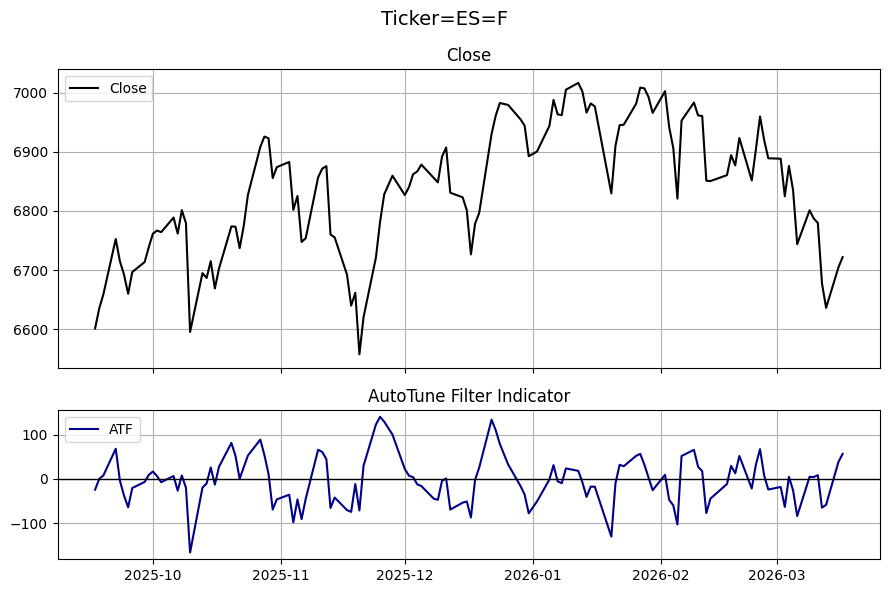

In [50]:
plot_autotune_filter(df[-126:])